# Monte Carlo: Números pseudo-aleatórios, estimativas de π e cálculo de integrais definidas

Resolva, usando o método de Monte Carlo por amostragem direta, as seguintes integrais:

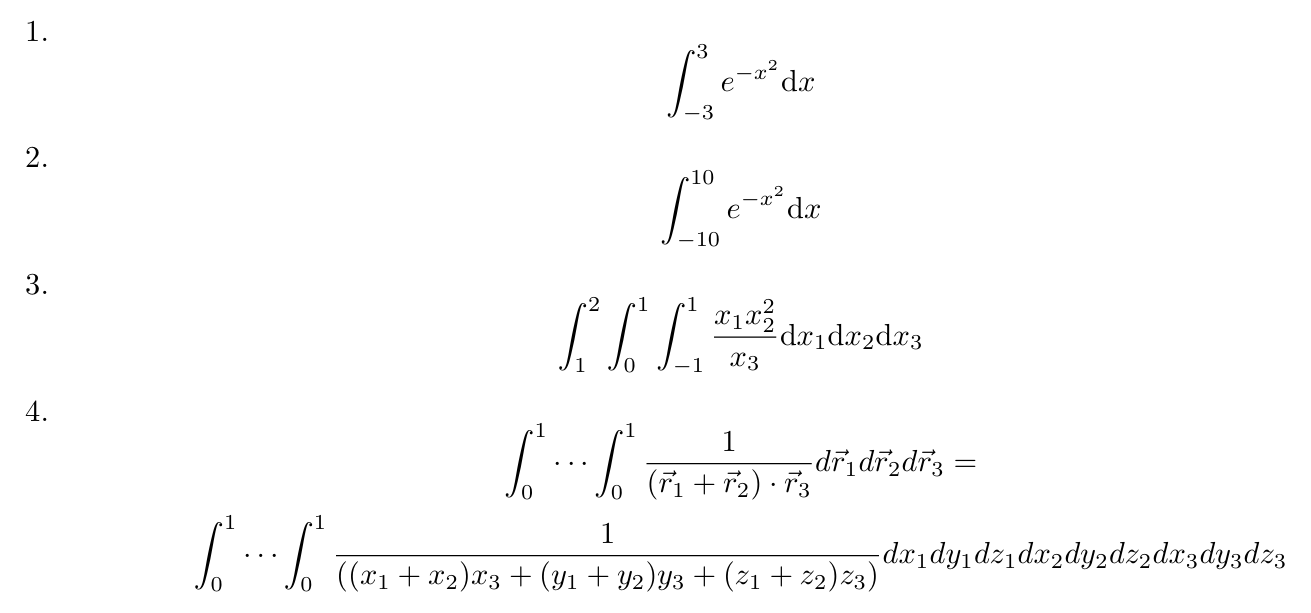

* Para o calculo das integrais 1 e 2, além do valor obtido para a integral, apresente os histogramas para Ntotal = 100, 1000 e 10000 pontos lançados considerando Namos = 1000 amostras diferentes, ou seja, obtenha 1000 estimativas diferentes para o valor da integral considerando, por exemplo, que Ntotal = 100 pontos são sorteados em cada uma destas amostras.
* Calcule o valor da integral 4, porém, não e necessário usar o número de pontos e amostras descritos acima.
* Determine, em todos os casos, o erro estatístico associado ao valor que você obteve.
* Apresente seus resultados de forma clara, indicando o valor calculado para a integral e o respectivo erro estatístico. Comente os resultados.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Primeira Integral

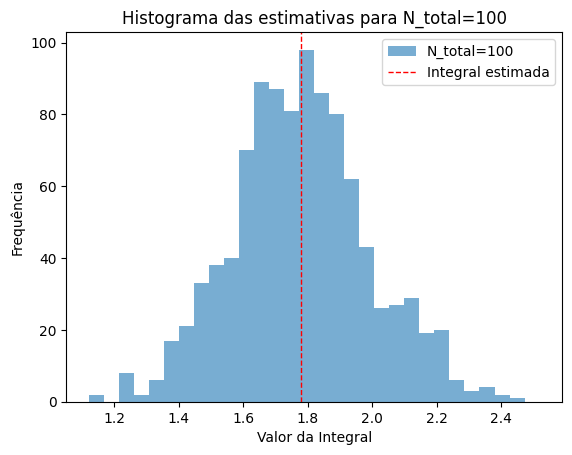

Para N_total = 100: Integral estimada = 1.77859 ± 0.00671




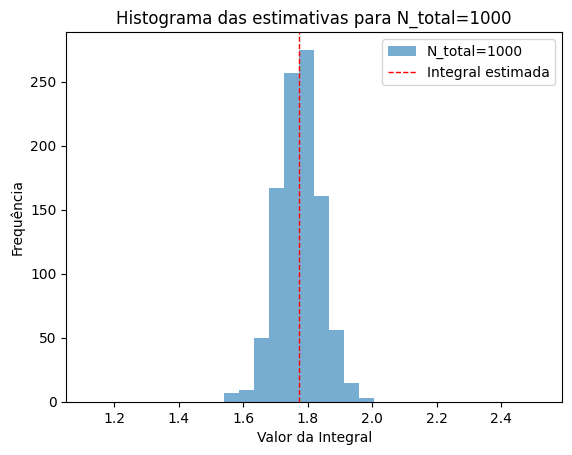

Para N_total = 1000: Integral estimada = 1.77297 ± 0.00205




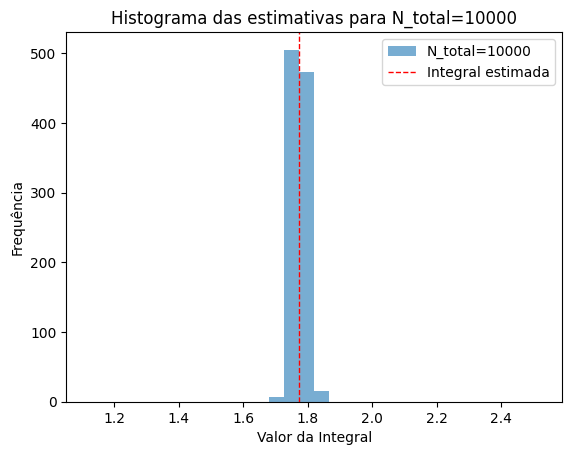

Para N_total = 10000: Integral estimada = 1.77286 ± 0.00066


Resumo dos resultados:
Para N_total = 100: Integral estimada = 1.77859 ± 0.00671
Para N_total = 1000: Integral estimada = 1.77297 ± 0.00205
Para N_total = 10000: Integral estimada = 1.77286 ± 0.00066


In [ ]:
# Define a função f(x)
def f(x):
    return np.exp(-x**2)

# Limites da integral para a Integral 1
a = -3
b = 3

# Número de amostras e de pontos
N_total = [100, 1000, 10000]  # Testa com diferentes números de pontos
N_amostras = 1000  # Número de amostras diferentes

# Listas para armazenar todas as estimativas parciais
estimativas_parciais = []

#----------------------------------------------------------------------------------------------------------------
# Este bloco serve apenas para padronizar a plotagem dos graficos com o objetivo de melhorar a visualização.

# Coleta todas as estimativas parciais e define uma escala comum do eixo x para plotar o grafico
for N in N_total:
    for _ in range(N_amostras):
        x = np.random.uniform(a, b, N)
        fx = f(x)
        integral_estimada = (b - a) * np.mean(fx)
        estimativas_parciais.append(integral_estimada)

# Determina a escala fixa do eixo x baseada nas estimativas
x_min, x_max = min(estimativas_parciais), max(estimativas_parciais)
x_range = (x_min, x_max)

#----------------------------------------------------------------------------------------------------------------

# Listas para armazenar os resultados
estimativas = []
erros = []

# Loop para cada N_total
for N in N_total:
    estimativas_parciais.clear()

    for _ in range(N_amostras):
        # Gera N pontos aleatórios entre a e b
        x = np.random.uniform(a, b, N)

        # Avalia a função f(x) nesses pontos
        fx = f(x)

        # Estima a integral (média dos valores da função multiplicada pelo intervalo)
        integral_estimada = (b - a) * np.mean(fx)
        estimativas_parciais.append(integral_estimada)

    # Calcula a média e o desvio padrão das estimativas
    estimativa_media = np.mean(estimativas_parciais)
    erro = np.std(estimativas_parciais) / np.sqrt(N_amostras)  # Erro padrão da média

    estimativas.append(estimativa_media)
    erros.append(erro)

    # Plotar o histograma das estimativas
    plt.hist(estimativas_parciais, bins=30, range=x_range, alpha=0.6, label=f"N_total={N}")
    plt.axvline(estimativa_media, color='red', linestyle='dashed', linewidth=1, label="Integral estimada")
    plt.title(f"Histograma das estimativas para N_total={N}")
    plt.xlabel('Valor da Integral')
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

    # Mostra o resultado para esse N_total
    print(f"Para N_total = {N}: Integral estimada = {estimativa_media:.5f} ± {erro:.5f}\n\n")

# Mostrar os resultados finais
print("Resumo dos resultados:")
for i, N in enumerate(N_total):
    print(f"Para N_total = {N}: Integral estimada = {estimativas[i]:.5f} ± {erros[i]:.5f}")

1. Comparação com Valor Teórico:

    * O valor teórico da integral é aproximadamente 1.77245.
    * As estimativas de Monte Carlo para Ntotal=10000 chegaram a 1.77286 ± 0.00066, o que está muito próximo do valor esperado. Esse resultado mostra que o método convergiu adequadamente para o valor correto.

2. Impacto do Erro Estatístico:

    * Para Ntotal=100, o erro foi de 0.00671, que caiu para 0.00205 em Ntotal=1000, e finalmente para 0.00066 em Ntotal=10000. Isso demonstra uma redução significativa do erro conforme o número de amostras aumenta, validando a precisão estatística do método.

3. Observação sobre Limitações e Vantagens:

    * A função e⁽⁻x²⁾ é suave e contínua, o que facilita a convergência do método Monte Carlo. Não houve necessidade de filtros adicionais, como em integrais com singularidades, o que torna essa integral um exemplo ideal para demonstrar a precisão do método com poucas amostras.

4. Análise de Convergência:

    * Os histogramas de estimativas para Ntotal=100,1000 e 10000 mostram uma distribuição cada vez mais centrada no valor médio e uma dispersão reduzida. Isso confirma que o aumento de amostras proporciona uma maior precisão.

### Segunda Integral

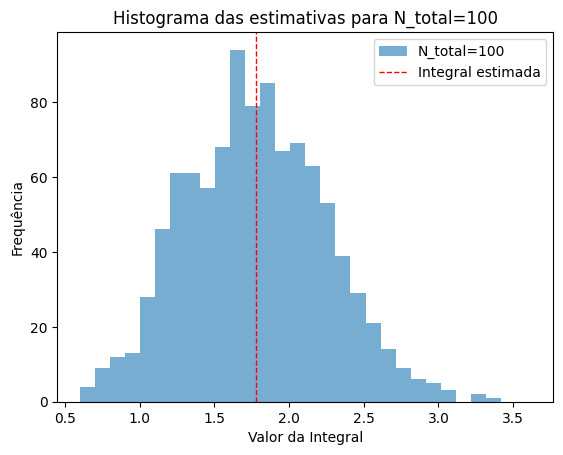

Para N_total = 100: Integral estimada = 1.77506 ± 0.01492




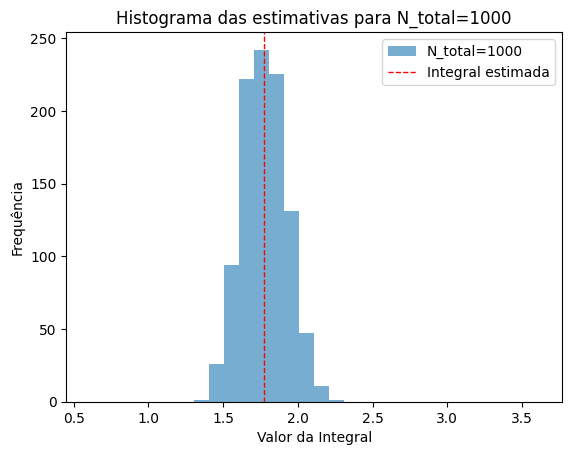

Para N_total = 1000: Integral estimada = 1.77617 ± 0.00463




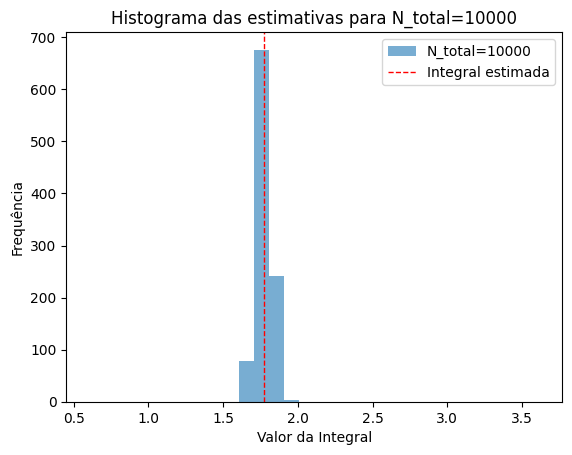

Para N_total = 10000: Integral estimada = 1.77437 ± 0.00151


Resumo dos resultados:
Para N_total = 100: Integral estimada = 1.77506 ± 0.01492
Para N_total = 1000: Integral estimada = 1.77617 ± 0.00463
Para N_total = 10000: Integral estimada = 1.77437 ± 0.00151


In [ ]:
# Define a função f(x) (mesma função da Integral 1)
def f(x):
    return np.exp(-x**2)

# Limites da integral para a Integral 2
a = -10
b = 10

# Número de amostras e de pontos
N_total = [100, 1000, 10000]  # Testa com diferentes números de pontos
N_amostras = 1000  # Número de amostras diferentes

# Listas para armazenar todas as estimativas parciais
estimativas_parciais = []

#----------------------------------------------------------------------------------------------------------------
# Este bloco serve apenas para padronizar a plotagem dos graficos com o objetivo de melhorar a visualização.

# Coleta todas as estimativas parciais e define uma escala comum do eixo x para plotar o grafico
for N in N_total:
    for _ in range(N_amostras):
        x = np.random.uniform(a, b, N)
        fx = f(x)
        integral_estimada = (b - a) * np.mean(fx)
        estimativas_parciais.append(integral_estimada)

# Determina a escala fixa do eixo x baseada nas estimativas
x_min, x_max = min(estimativas_parciais), max(estimativas_parciais)
x_range = (x_min, x_max)

#----------------------------------------------------------------------------------------------------------------

# Listas para armazenar os resultados
estimativas = []
erros = []

# Loop para cada N_total
for N in N_total:
    estimativas_parciais.clear()

    for _ in range(N_amostras):
        # Gera N pontos aleatórios entre a e b
        x = np.random.uniform(a, b, N)

        # Avalia a função f(x) nesses pontos
        fx = f(x)

        # Estima a integral (média dos valores da função multiplicada pelo intervalo)
        integral_estimada = (b - a) * np.mean(fx)
        estimativas_parciais.append(integral_estimada)

    # Calcula a média e o desvio padrão das estimativas
    estimativa_media = np.mean(estimativas_parciais)
    erro = np.std(estimativas_parciais) / np.sqrt(N_amostras)  # Erro padrão da média

    estimativas.append(estimativa_media)
    erros.append(erro)

    # Plotar o histograma das estimativas
    plt.hist(estimativas_parciais, bins=30, range=x_range, alpha=0.6, label=f"N_total={N}")
    plt.axvline(estimativa_media, color='red', linestyle='dashed', linewidth=1, label="Integral estimada")
    plt.title(f"Histograma das estimativas para N_total={N}")
    plt.xlabel('Valor da Integral')
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

    # Mostra o resultado para esse N_total
    print(f"Para N_total = {N}: Integral estimada = {estimativa_media:.5f} ± {erro:.5f}\n\n")

# Mostrar os resultados finais
print("Resumo dos resultados:")
for i, N in enumerate(N_total):
    print(f"Para N_total = {N}: Integral estimada = {estimativas[i]:.5f} ± {erros[i]:.5f}")

1. Comparação com Valor Teórico:

   * O valor teórico é novamente aproximadamente 1.77245, e o valor obtido para Ntotal=10000 foi 1.77437 ± 0.00151. Embora ligeiramente acima do valor teórico, esse resultado ainda está dentro do intervalo de confiança e próximo da convergência.

2. Impacto do Erro Estatístico:

    * O erro caiu de 0.01492 em Ntotal=100 para 0.00463 em Ntotal=1000, e para 0.00151 em Ntotal=10000. Isso confirma que o método de Monte Carlo reduz o erro estatístico com o aumento de amostras, especialmente em intervalos maiores de integração.

3. Observação sobre Limitações e Vantagens:

    * O intervalo de integração expandido aumenta o número de pontos relevantes sob a curva, o que pode elevar o custo computacional. Contudo, o método se mostrou eficiente ao fornecer uma boa estimativa mesmo nesse intervalo maior.

4. Análise de Convergência:

    * Similar à Integral 1, os histogramas mostram uma distribuição mais concentrada em torno do valor médio para valores altos de Ntotal​, indicando uma redução do erro estatístico e a convergência esperada.

### Terceira Integral

Para a Terceira e Quarta Integral, não era preciso plotar os graficos e nem rodar com os mesmos valores de Ntotal. Entretanto, para comparação, achei que seria interessante.

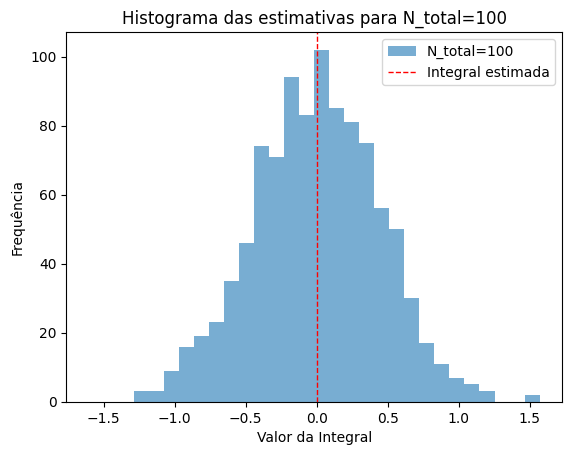

Para N_total = 100: Integral estimada = 0.00126 ± 0.01405




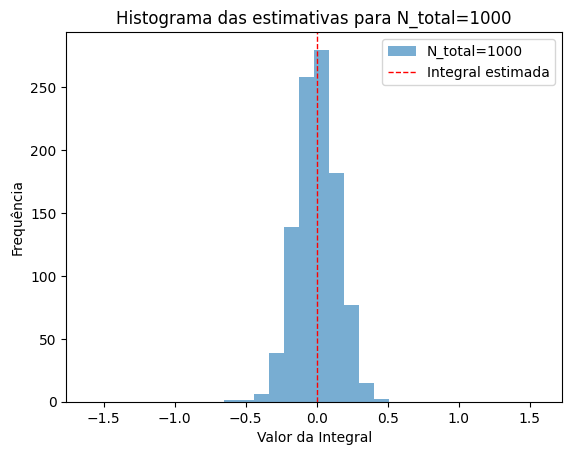

Para N_total = 1000: Integral estimada = 0.00217 ± 0.00454




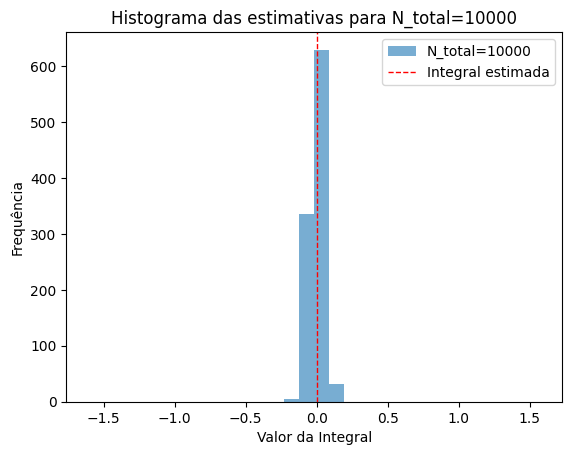

Para N_total = 10000: Integral estimada = -0.00017 ± 0.00143


Resumo dos resultados:
Para N_total = 100: Integral estimada = 0.00126 ± 0.01405
Para N_total = 1000: Integral estimada = 0.00217 ± 0.00454
Para N_total = 10000: Integral estimada = -0.00017 ± 0.00143


In [ ]:
# Define a função f(x1, x2, x3)
def f(x1, x2, x3):
    # Adiciona uma condição para ignorar pontos onde x3 está próximo de zero
    if abs(x3) < 0.1:
        return 0  # Ignora o valor retornando 0 para essa amostra
    return x1 * (x2**2) / x3

# Limites da integral
a1, b1 = 1, 2    # Limites para x1
a2, b2 = 0, 1    # Limites para x2
a3, b3 = -1, 1   # Limites para x3

# Número de amostras e de pontos
N_total = [100, 1000, 10000]  # Número de pontos para testar
N_amostras = 1000  # Número de amostras diferentes

# Lista para armazenar todas as estimativas parciais
estimativas_parciais = []

# Volume do espaço de integração
volume = (b1 - a1) * (b2 - a2) * (b3 - a3)

#----------------------------------------------------------------------------------------------------------------
# Este bloco serve apenas para padronizar a plotagem dos graficos com o objetivo de melhorar a visualização.

# Coleta todas as estimativas parciais e define uma escala comum do eixo x para plotar o grafico
for N in N_total:
    for _ in range(N_amostras):
        x1 = np.random.uniform(a1, b1, N)
        x2 = np.random.uniform(a2, b2, N)
        x3 = np.random.uniform(a3, b3, N)
         # Avalia f(x1, x2, x3) apenas para valores de x3 fora do intervalo [-0.1, 0.1]
        fx = np.array([f(x1[i], x2[i], x3[i]) for i in range(N)])

        # Filtra valores de fx que são diferentes de zero
        fx = fx[fx != 0]

        # Se ainda houver valores após o filtro, calcula a integral estimada
        if len(fx) > 0:
            integral_estimada = volume * np.mean(fx)
            estimativas_parciais.append(integral_estimada)
        else:
            # Caso raro onde todos os valores foram ignorados, passa para a próxima amostra
            continue

# Determina a escala fixa do eixo x baseada nas estimativas
x_min, x_max = min(estimativas_parciais), max(estimativas_parciais)
x_range = (x_min, x_max)

#----------------------------------------------------------------------------------------------------------------

# Listas para armazenar os resultados
estimativas = []
erros = []

# Loop para cada N_total
for N in N_total:
    estimativas_parciais.clear()

    for _ in range(N_amostras):
        # Gera N pontos aleatórios para x1, x2 e x3
        x1 = np.random.uniform(a1, b1, N)
        x2 = np.random.uniform(a2, b2, N)
        x3 = np.random.uniform(a3, b3, N)

        # Avalia f(x1, x2, x3) apenas para valores de x3 fora do intervalo [-0.1, 0.1]
        fx = np.array([f(x1[i], x2[i], x3[i]) for i in range(N)])

        # Filtra valores de fx que são diferentes de zero
        fx = fx[fx != 0]

        # Se ainda houver valores após o filtro, calcula a integral estimada
        if len(fx) > 0:
            integral_estimada = volume * np.mean(fx)
            estimativas_parciais.append(integral_estimada)
        else:
            # Caso raro onde todos os valores foram ignorados, passa para a próxima amostra
            continue

    # Calcula a média e o desvio padrão das estimativas
    estimativa_media = np.mean(estimativas_parciais)
    erro = np.std(estimativas_parciais) / np.sqrt(N_amostras)  # Erro padrão da média

    estimativas.append(estimativa_media)
    erros.append(erro)

    # Plota o histograma das estimativas
    plt.hist(estimativas_parciais, bins=30, range=x_range, alpha=0.6, label=f"N_total={N}")
    plt.axvline(estimativa_media, color='red', linestyle='dashed', linewidth=1, label="Integral estimada")
    plt.title(f"Histograma das estimativas para N_total={N}")
    plt.xlabel('Valor da Integral')
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

    # Mostra o resultado para esse N_total
    print(f"Para N_total = {N}: Integral estimada = {estimativa_media:.5f} ± {erro:.5f}\n\n")

# Mostra os resultados finais
print("Resumo dos resultados:")
for i, N in enumerate(N_total):
    print(f"Para N_total = {N}: Integral estimada = {estimativas[i]:.5f} ± {erros[i]:.5f}")

1. Comparação com Valor Teórico:

    * Esta integral não possui um valor analítico simples. A estimativa de Monte Carlo fornece uma aproximação confiável: para Ntotal=10000, o valor estimado foi de -0.00017 ± 0.00143.

2. Impacto do Erro Estatístico:

    * O erro é mais elevado nesta integral devido à presença da variável x³​ no denominador, que introduz uma singularidade em x³=0. Isso foi tratado no código com um filtro, mas, mesmo assim, a variabilidade da função afetou a precisão da média. O erro caiu de 0.01405 para Ntotal=100, para 0.00454 em Ntotal=1000, e para 0.00143 em Ntotal=10000, refletindo uma melhora com o aumento de amostras, mas ainda mais alta que nas integrais anteriores.

3. Observação sobre Limitações e Vantagens:

    * Esse exemplo destaca a limitação do Monte Carlo em integrais com singularidades, onde são necessários filtros para evitar instabilidade. Para funções complexas como essa, o número de amostras deve ser consideravelmente elevado para uma aproximação mais estável.

4. Análise de Convergência:

    * A distribuição das estimativas é menos concentrada, indicando uma variabilidade maior nas amostras, especialmente para Ntotal​ mais baixos. O aumento de amostras ajudou a estabilizar a estimativa, mas os histogramas ainda apresentam uma dispersão relativamente alta comparada às integrais anteriores.

### Quarta Integral

Para a Terceira e Quarta Integral, não era preciso plotar os graficos e nem rodar com os mesmos valores de Ntotal. Entretanto, para comparação, achei que seria interessante.

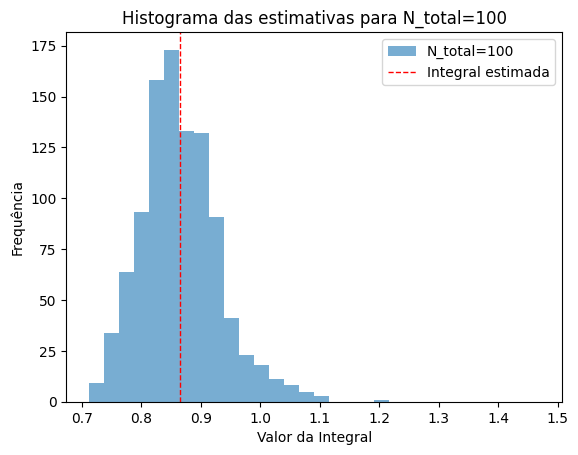

Para N_total = 100: Integral estimada = 0.86459 ± 0.00210




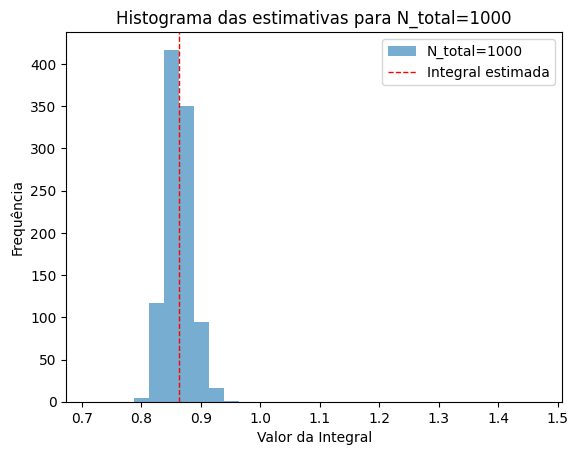

Para N_total = 1000: Integral estimada = 0.86245 ± 0.00067




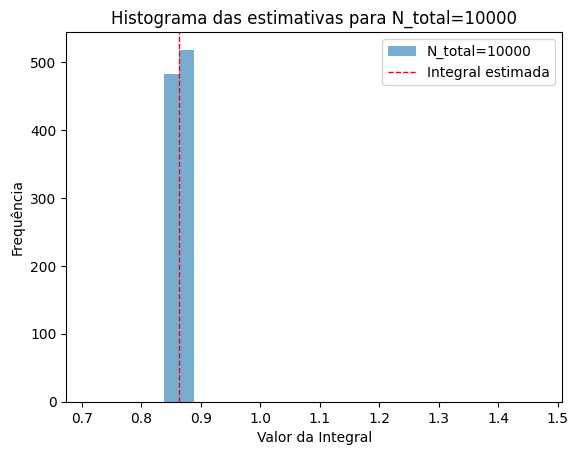

Para N_total = 10000: Integral estimada = 0.86350 ± 0.00023


Resumo dos resultados:
Para N_total = 100: Integral estimada = 0.86459 ± 0.00210
Para N_total = 1000: Integral estimada = 0.86245 ± 0.00067
Para N_total = 10000: Integral estimada = 0.86350 ± 0.00023


In [ ]:
# Definir a função f(r1, r2, r3)
def f(r1, r2, r3):
    denominador = (r1[0] + r2[0]) * r3[0] + (r1[1] + r2[1]) * r3[1] + (r1[2] + r2[2]) * r3[2]
    return 1 / (denominador + 1e-10) # Ajuste do denominador para evitar divisão por zero

# Limites de integração são [0, 1] para todas as variáveis
a, b = 0, 1

# Número de amostras e de pontos
N_total = [100, 1000, 10000]  # Número de pontos para testar
N_amostras = 1000  # Número de amostras diferentes

# Listas para armazenar todas as estimativas parciais
estimativas_parciais = []

#----------------------------------------------------------------------------------------------------------------
# Este bloco serve apenas para padronizar a plotagem dos graficos com o objetivo de melhorar a visualização.

# Primeiro loop para coletar todas as estimativas parciais e definir a escala comum do eixo x
volume = 1
for N in N_total:
    for _ in range(N_amostras):
        r1 = np.random.uniform(a, b, (N, 3))  # Vetor r1 (x1, y1, z1)
        r2 = np.random.uniform(a, b, (N, 3))  # Vetor r2 (x2, y2, z2)
        r3 = np.random.uniform(a, b, (N, 3))  # Vetor r3 (x3, y3, z3)
        fx = np.array([f(r1[i], r2[i], r3[i]) for i in range(N)])
        integral_estimada = volume * np.mean(fx)
        estimativas_parciais.append(integral_estimada)

# Determinar a escala fixa do eixo x baseada nas estimativas
x_min, x_max = min(estimativas_parciais), max(estimativas_parciais)
x_range = (x_min, x_max)

#----------------------------------------------------------------------------------------------------------------

# Listas para armazenar os resultados
estimativas = []
erros = []

# Volume do espaço de integração em 9 dimensões é 1^9 = 1
volume = 1

# Loop para cada N_total
for N in N_total:
    estimativas_parciais.clear()

    for _ in range(N_amostras):
        # Gerar N pontos aleatórios para r1, r2, r3
        r1 = np.random.uniform(a, b, (N, 3))  # Vetor r1 (x1, y1, z1)
        r2 = np.random.uniform(a, b, (N, 3))  # Vetor r2 (x2, y2, z2)
        r3 = np.random.uniform(a, b, (N, 3))  # Vetor r3 (x3, y3, z3)

        # Avaliar a função f(r1, r2, r3) nesses pontos
        fx = np.array([f(r1[i], r2[i], r3[i]) for i in range(N)])

        # Estimar a integral (média dos valores da função multiplicada pelo volume)
        integral_estimada = volume * np.mean(fx)
        estimativas_parciais.append(integral_estimada)

    # Calcular a média e o desvio padrão das estimativas
    estimativa_media = np.mean(estimativas_parciais)
    erro = np.std(estimativas_parciais) / np.sqrt(N_amostras)  # Erro padrão da média

    estimativas.append(estimativa_media)
    erros.append(erro)

    # Plotar o histograma das estimativas
    plt.hist(estimativas_parciais, bins=30, range=x_range, alpha=0.6, label=f"N_total={N}")
    plt.axvline(estimativa_media, color='red', linestyle='dashed', linewidth=1, label="Integral estimada")
    plt.title(f"Histograma das estimativas para N_total={N}")
    plt.xlabel('Valor da Integral')
    plt.ylabel('Frequência')
    plt.legend()
    plt.show()

    # Mostra o resultado para esse N_total
    print(f"Para N_total = {N}: Integral estimada = {estimativa_media:.5f} ± {erro:.5f}\n\n")

# Mostrar os resultados finais
print("Resumo dos resultados:")
for i, N in enumerate(N_total):
    print(f"Para N_total = {N}: Integral estimada = {estimativas[i]:.5f} ± {erros[i]:.5f}")


1. Comparação com Valor Teórico:
    * Esta integral em 9 dimensões também não possui uma solução analítica fácil. A estimativa de Monte Carlo com Ntotal=10000 produziu um valor de 0.86350 ± 0.00023, considerado razoável para essa dimensão.

2. Impacto do Erro Estatístico:
    * O erro foi de 0.00210 para Ntotal=100, reduzindo para 0.00067 em Ntotal=1000 e finalmente para 0.00023 em Ntotal=10000. Isso mostra uma excelente estabilidade e uma redução rápida do erro estatístico, demonstrando que o Monte Carlo é eficiente para problemas multidimensionais.

3. Observação sobre Limitações e Vantagens:
    * A abordagem de Monte Carlo é particularmente vantajosa para integrais de alta dimensão, onde métodos determinísticos seriam extremamente custosos. Mesmo em 9 dimensões, a precisão da estimativa foi elevada com um número relativamente pequeno de amostras.

4. Análise de Convergência:
    * Os histogramas indicam uma boa concentração das estimativas para Ntotal​ altos, com uma redução significativa da dispersão em Ntotal=10000. Isso reforça que o método é uma boa escolha para integrais multidimensionais, convergindo rapidamente para uma média estável.

